In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
 
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import (
    Dense, Flatten, Dropout, BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
 
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

In [13]:
DATASET_DIR   = "./Data"           # Sesuaikan path dataset Kaggle
IMG_SIZE      = (224, 224)         # Input VGG16
BATCH_SIZE    = 32
EPOCHS_FREEZE   = 10               # Train head, base frozen
EPOCHS_UNFREEZE = 10               # Fine-tune block5
LEARNING_RATE   = 1e-4
SEED          = 42
NUM_CLASSES   = 3                  # COVID / Normal / Pneumonia
 
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
TEST_DIR  = os.path.join(DATASET_DIR, "test")
 
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [14]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)
 
test_datagen = ImageDataGenerator(rescale=1.0 / 255)
 
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    seed=SEED
)
 
val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    seed=SEED
)
 
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)
 
CLASS_NAMES = list(train_generator.class_indices.keys())
print("Kelas terdeteksi:", CLASS_NAMES)

Found 4116 images belonging to 3 classes.
Found 1028 images belonging to 3 classes.
Found 1288 images belonging to 3 classes.
Kelas terdeteksi: ['COVID19', 'NORMAL', 'PNEUMONIA']


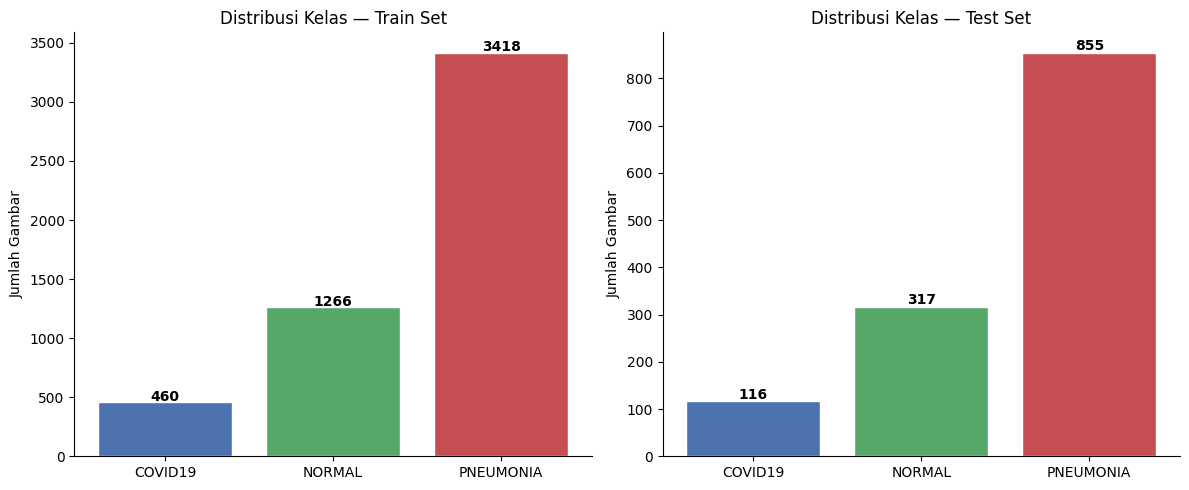

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Hitung distribusi
train_dist = {kelas: len(os.listdir(os.path.join(TRAIN_DIR, kelas))) 
              for kelas in CLASS_NAMES}
test_dist  = {kelas: len(os.listdir(os.path.join(TEST_DIR, kelas))) 
              for kelas in CLASS_NAMES}

colors = ["#4C72B0", "#55A868", "#C44E52"]

# Train
axes[0].bar(train_dist.keys(), train_dist.values(), color=colors, edgecolor="white")
for i, (k, v) in enumerate(train_dist.items()):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")
axes[0].set_title("Distribusi Kelas — Train Set", fontsize=12)
axes[0].set_ylabel("Jumlah Gambar")
axes[0].spines[["top", "right"]].set_visible(False)

# Test
axes[1].bar(test_dist.keys(), test_dist.values(), color=colors, edgecolor="white")
for i, (k, v) in enumerate(test_dist.items()):
    axes[1].text(i, v + 5, str(v), ha="center", fontweight="bold")
axes[1].set_title("Distribusi Kelas — Test Set", fontsize=12)
axes[1].set_ylabel("Jumlah Gambar")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

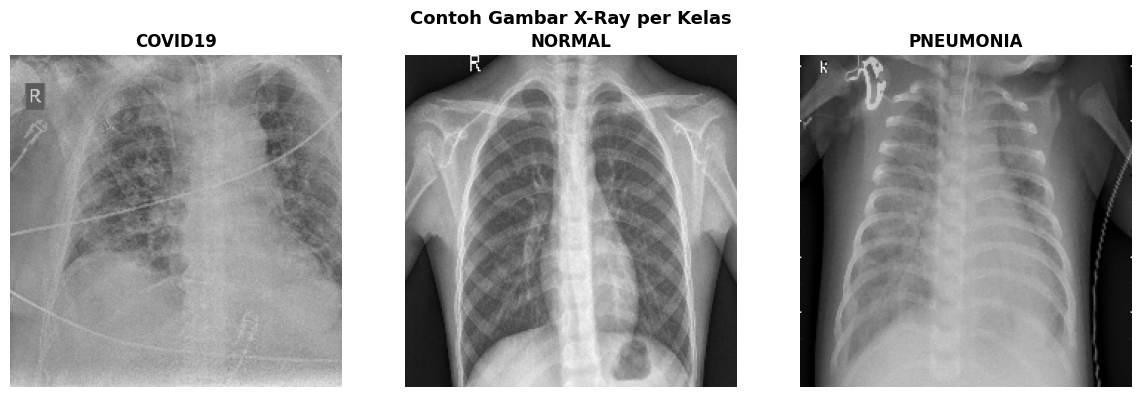

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle("Contoh Gambar X-Ray per Kelas", fontsize=13, fontweight="bold")

for i, kelas in enumerate(CLASS_NAMES):
    path_kelas = os.path.join(TRAIN_DIR, kelas)
    nama_file  = os.listdir(path_kelas)[0]
    img = tf.keras.preprocessing.image.load_img(
        os.path.join(path_kelas, nama_file),
        target_size=IMG_SIZE
    )
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(kelas, fontsize=12, fontweight="bold")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [16]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
 
# Freeze semua layer base pada tahap awal
base_model.trainable = False
 
x = base_model.output
x = Flatten()(x)
x = Dense(4096, activation="relu")(x)
x = Dropout(0.5)(x)
x = Dense(4096, activation="relu")(x)
x = Dropout(0.5)(x)
x = BatchNormalization()(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)
 
model = Model(inputs=base_model.input, outputs=output)
 
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
 
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 4096)           │        16,38

 Total params: 134,289,219 (512.27 MB)

 Trainable params: 119,566,339 (456.11 MB)

 Non-trainable params: 14,722,880 (56.16 MB)

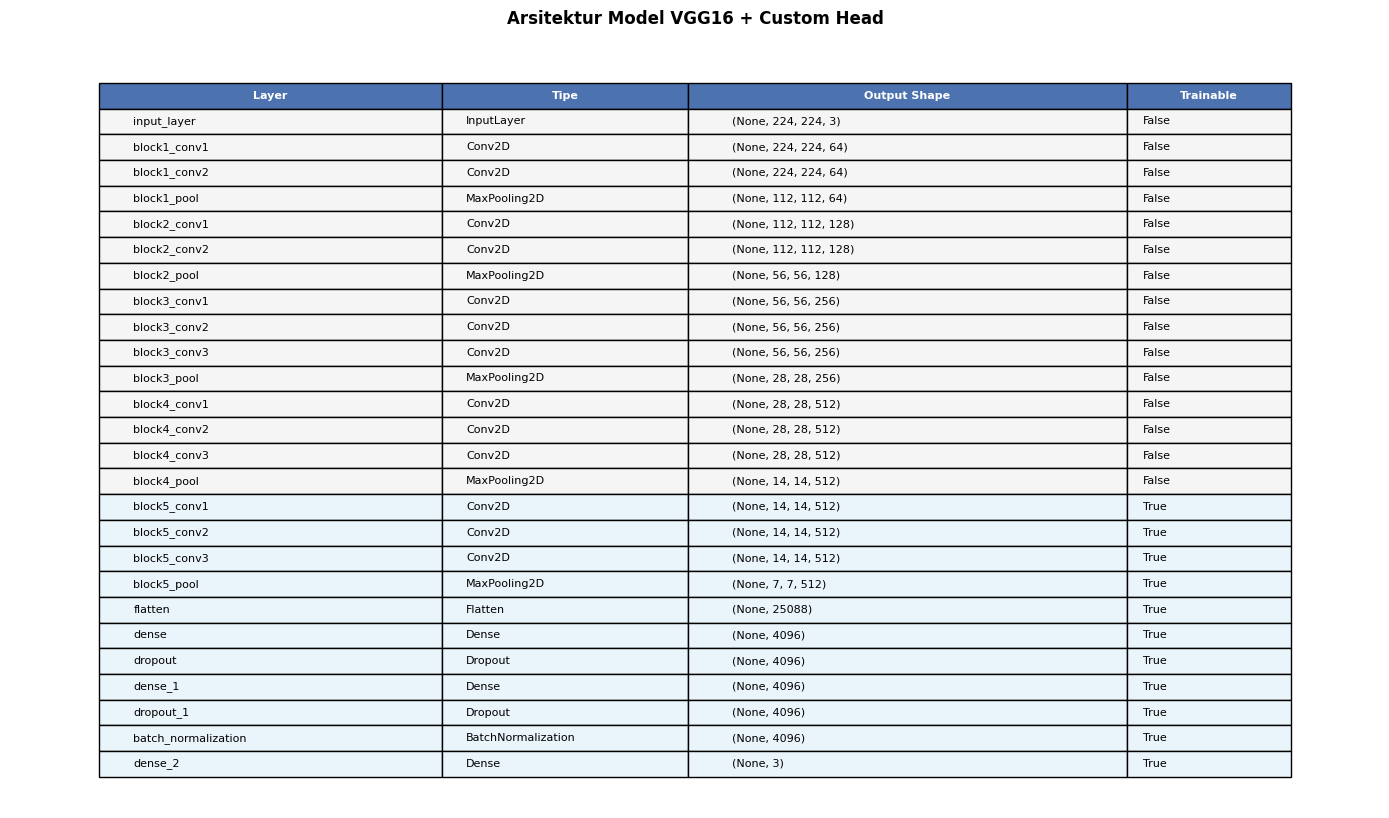

In [21]:
import pandas as pd

ringkasan = []
for layer in model.layers:
    # Tangani InputLayer yang tidak punya output_shape
    try:
        output_shape = str(layer.output_shape)
    except AttributeError:
        output_shape = str(layer.output.shape)

    ringkasan.append({
        "Layer"        : layer.name,
        "Tipe"         : layer.__class__.__name__,
        "Output Shape" : output_shape,
        "Trainable"    : layer.trainable
    })

df_summary = pd.DataFrame(ringkasan)

fig, ax = plt.subplots(figsize=(14, len(df_summary) * 0.28 + 1))
ax.axis("off")

tabel = ax.table(
    cellText=df_summary.values,
    colLabels=df_summary.columns,
    cellLoc="left",
    loc="center",
    colWidths=[0.25, 0.18, 0.32, 0.12]
)
tabel.auto_set_font_size(False)
tabel.set_fontsize(8)
tabel.scale(1, 1.3)

for j in range(len(df_summary.columns)):
    tabel[0, j].set_facecolor("#4C72B0")
    tabel[0, j].set_text_props(color="white", fontweight="bold")

for i in range(1, len(df_summary) + 1):
    warna = "#EAF4FB" if df_summary.iloc[i-1]["Trainable"] else "#F5F5F5"
    for j in range(len(df_summary.columns)):
        tabel[i, j].set_facecolor(warna)

ax.set_title("Arsitektur Model VGG16 + Custom Head",
             fontsize=12, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

In [5]:
# Callbacks

checkpoint_cb = ModelCheckpoint(
    "best_vgg16_xray.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)
 
earlystop_cb = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)
 
reduce_lr_cb = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

In [6]:
print("\n[TAHAP 1] Training head, base frozen...")
history_freeze = model.fit(
    train_generator,
    epochs=EPOCHS_FREEZE,
    validation_data=val_generator,
    callbacks=[checkpoint_cb, earlystop_cb, reduce_lr_cb]
)
 


[TAHAP 1] Training head, base frozen...
Epoch 1/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.5901 - loss: 1.0132 
Epoch 1: val_accuracy improved from None to 0.88619, saving model to best_vgg16_xray.keras

Epoch 1: finished saving model to best_vgg16_xray.keras
129/129 ━━━━━━━━━━━━━━━━━━━━ 1601s 12s/step - accuracy: 0.6713 - loss: 0.8374 - val_accuracy: 0.8862 - val_loss: 0.3021 - learning_rate: 1.0000e-04
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.7878 - loss: 0.5875
Epoch 2: val_accuracy improved from 0.88619 to 0.92704, saving model to best_vgg16_xray.keras

Epoch 2: finished saving model to best_vgg16_xray.keras
129/129 ━━━━━━━━━━━━━━━━━━━━ 1575s 12s/step - accuracy: 0.8022 - loss: 0.5464 - val_accuracy: 0.9270 - val_loss: 0.2504 - learning_rate: 1.0000e-04
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.8485 - loss: 0.4424
Epoch 3: val_accuracy did not improve from 0.92704
129/129 ━━━━━━━━━━━━━━━━━━━━ 1571s 12s/step - accuracy

In [7]:
print("\n[TAHAP 2] Fine-tuning block5_conv1~3 + FC...")
for layer in base_model.layers:
    layer.trainable = layer.name.startswith("block5")
 
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE / 10),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
 
history_unfreeze = model.fit(
    train_generator,
    epochs=EPOCHS_UNFREEZE,
    validation_data=val_generator,
    callbacks=[checkpoint_cb, earlystop_cb, reduce_lr_cb]
)


[TAHAP 2] Fine-tuning block5_conv1~3 + FC...
Epoch 1/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.9328 - loss: 0.2150 
Epoch 1: val_accuracy improved from 0.94844 to 0.95331, saving model to best_vgg16_xray.keras

Epoch 1: finished saving model to best_vgg16_xray.keras
129/129 ━━━━━━━━━━━━━━━━━━━━ 1951s 15s/step - accuracy: 0.9356 - loss: 0.2065 - val_accuracy: 0.9533 - val_loss: 0.1550 - learning_rate: 1.0000e-05
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.9459 - loss: 0.1617 
Epoch 2: val_accuracy did not improve from 0.95331
129/129 ━━━━━━━━━━━━━━━━━━━━ 1894s 15s/step - accuracy: 0.9446 - loss: 0.1741 - val_accuracy: 0.9446 - val_loss: 0.1848 - learning_rate: 1.0000e-05
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.9544 - loss: 0.1463 
Epoch 3: val_accuracy did not improve from 0.95331
129/129 ━━━━━━━━━━━━━━━━━━━━ 1896s 15s/step - accuracy: 0.9519 - loss: 0.1539 - val_accuracy: 0.9533 - val_loss: 0.1624 - learning_rate: 1.0000e

In [17]:
all_acc     = history_freeze.history["accuracy"]     + history_unfreeze.history["accuracy"]
all_val_acc = history_freeze.history["val_accuracy"] + history_unfreeze.history["val_accuracy"]
all_loss    = history_freeze.history["loss"]         + history_unfreeze.history["loss"]
all_val_loss= history_freeze.history["val_loss"]     + history_unfreeze.history["val_loss"]

NameError: name 'history_freeze' is not defined

In [18]:
print("\nEvaluasi pada test set...")
model.load_weights("best_vgg16_xray.keras")
 
test_generator.reset()
y_pred_prob = model.predict(test_generator, verbose=1)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = test_generator.classes
 
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


Evaluasi pada test set...
41/41 ━━━━━━━━━━━━━━━━━━━━ 398s 10s/step

Classification Report:
              precision    recall  f1-score   support

     COVID19       1.00      0.98      0.99       116
      NORMAL       0.79      0.98      0.87       317
   PNEUMONIA       0.99      0.91      0.95       855

    accuracy                           0.93      1288
   macro avg       0.93      0.96      0.94      1288
weighted avg       0.94      0.93      0.93      1288



C:\Users\Owner\AppData\Local\Temp\ipykernel_2076\804851149.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


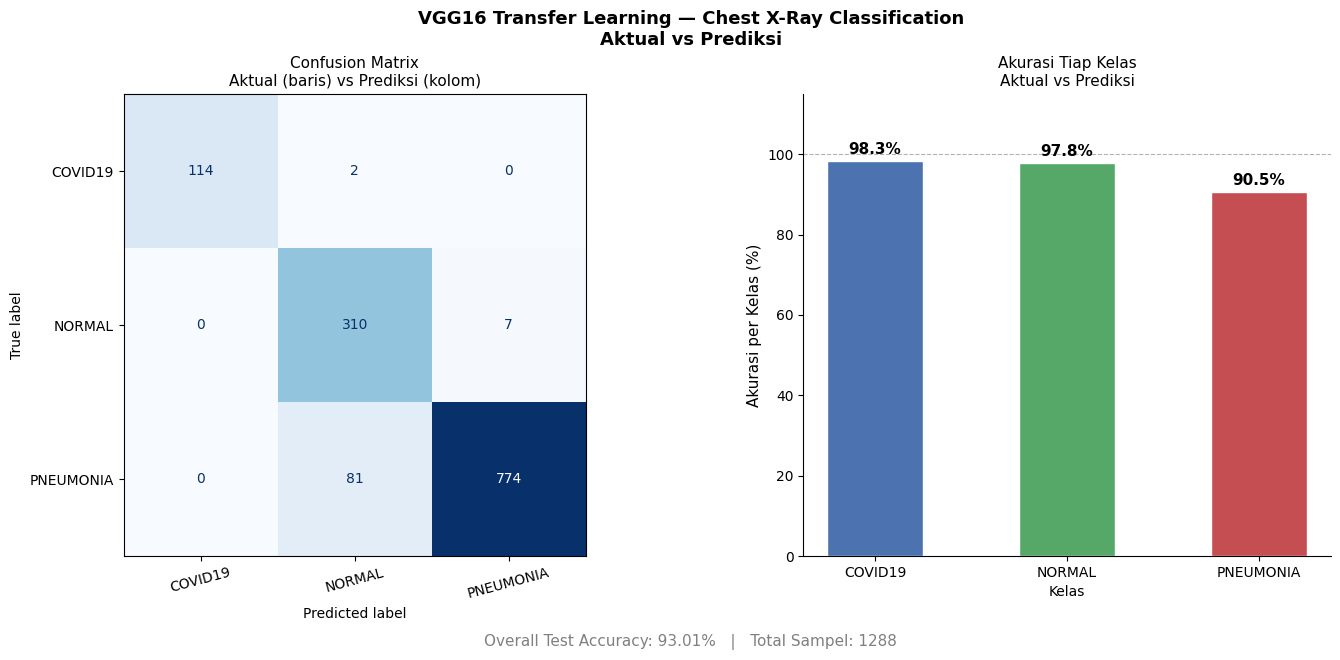

In [19]:
cm = confusion_matrix(y_true, y_pred)
overall_acc = np.sum(cm.diagonal()) / np.sum(cm)
per_class_acc = cm.diagonal() / cm.sum(axis=1)
 
fig = plt.figure(figsize=(16, 6))
fig.suptitle(
    "VGG16 Transfer Learning — Chest X-Ray Classification\n"
    "Aktual vs Prediksi",
    fontsize=13, fontweight="bold", y=1.02
)
 
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)
 
# --- Panel kiri: Confusion Matrix ---
ax1 = fig.add_subplot(gs[0, 0])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax1, colorbar=False, cmap="Blues")
ax1.set_title("Confusion Matrix\nAktual (baris) vs Prediksi (kolom)", fontsize=11)
ax1.tick_params(axis="x", rotation=15)
 
# --- Panel kanan: Per-kelas akurasi bar ---
ax2 = fig.add_subplot(gs[0, 1])
colors = ["#4C72B0", "#55A868", "#C44E52"]
bars = ax2.bar(CLASS_NAMES, per_class_acc * 100, color=colors, edgecolor="white", width=0.5)
 
for bar, acc in zip(bars, per_class_acc):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{acc*100:.1f}%",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )
 
ax2.set_ylim(0, 115)
ax2.set_ylabel("Akurasi per Kelas (%)", fontsize=11)
ax2.set_title("Akurasi Tiap Kelas\nAktual vs Prediksi", fontsize=11)
ax2.set_xlabel("Kelas")
ax2.spines[["top", "right"]].set_visible(False)
ax2.axhline(100, linestyle="--", color="gray", linewidth=0.8, alpha=0.6)
 
fig.text(
    0.5, -0.04,
    f"Overall Test Accuracy: {overall_acc*100:.2f}%   |   Total Sampel: {len(y_true)}",
    ha="center", fontsize=11, color="gray"
)
 
plt.tight_layout()
# plt.savefig("aktual_vs_prediksi_vgg16.png", dpi=150, bbox_inches="tight")
plt.show()
# print("\nVisualisasi disimpan: aktual_vs_prediksi_vgg16.png")

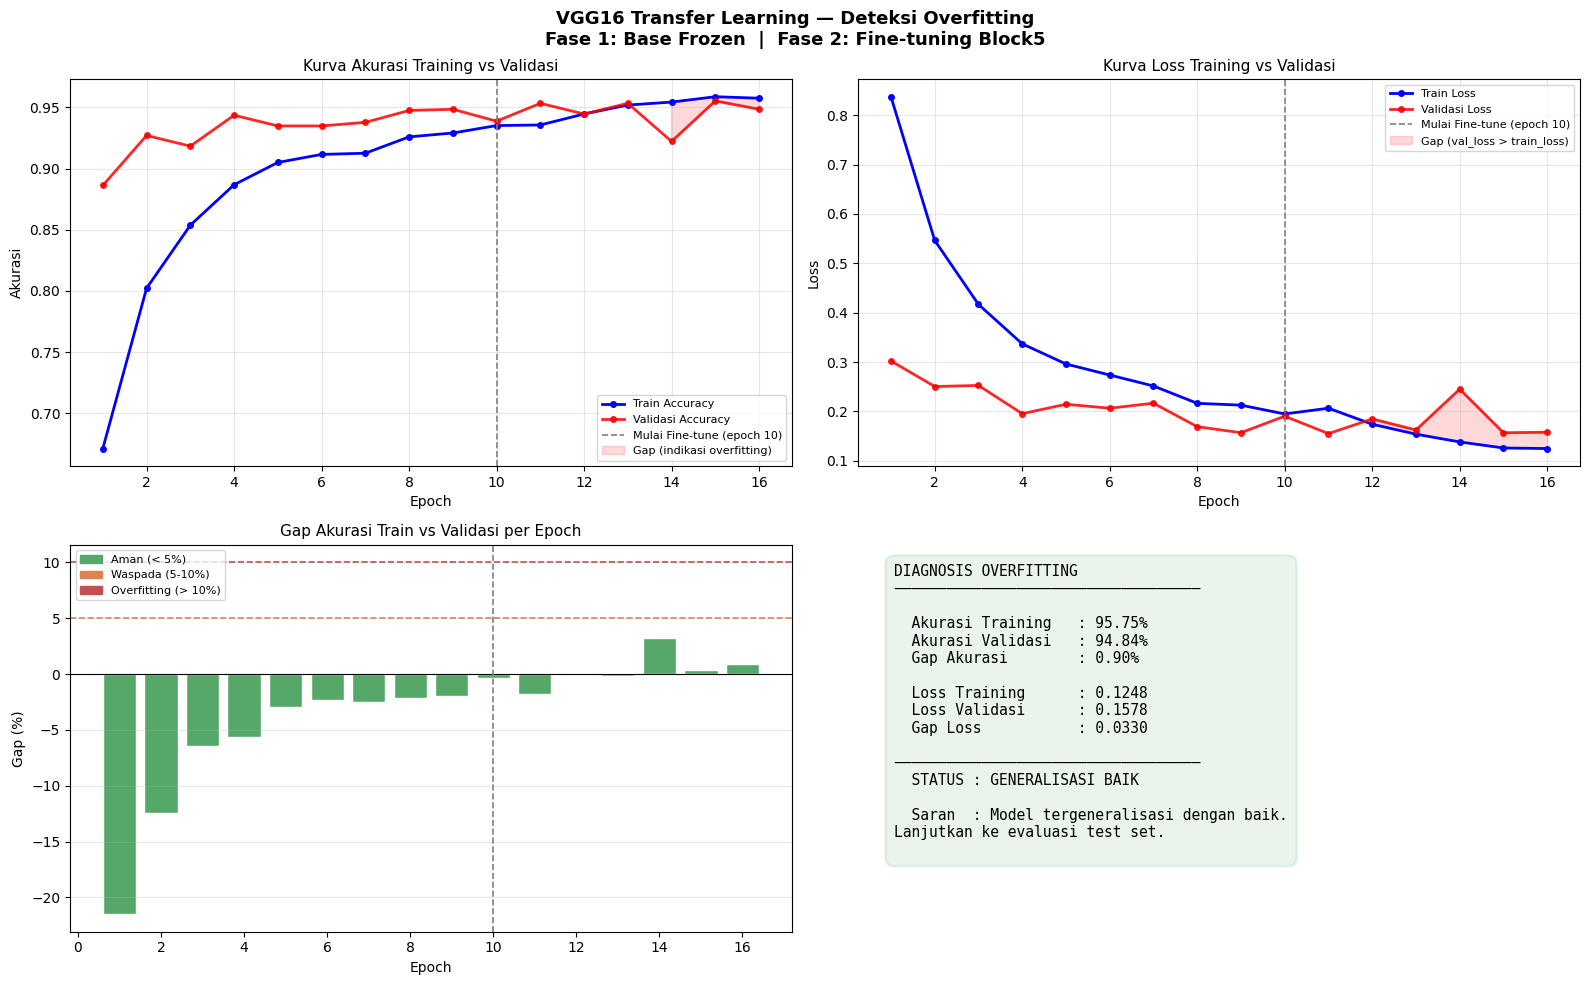

In [13]:
# ============================================================
# VISUALISASI LENGKAP: KURVA TRAINING + DETEKSI OVERFITTING
# ============================================================

epochs_freeze   = len(history_freeze.history["accuracy"])
epochs_unfreeze = len(history_unfreeze.history["accuracy"])
total_epochs    = epochs_freeze + epochs_unfreeze
x_all           = range(1, total_epochs + 1)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    "VGG16 Transfer Learning — Deteksi Overfitting\n"
    "Fase 1: Base Frozen  |  Fase 2: Fine-tuning Block5",
    fontsize=13, fontweight="bold"
)

# Warna dan garis pemisah fase
FREEZE_COLOR   = "#4C72B0"
UNFREEZE_COLOR = "#C44E52"
VAL_ALPHA      = 0.85

# ── Panel 1: Accuracy curve ──────────────────────────────
ax = axes[0, 0]
ax.plot(x_all, all_acc,     "b-o", markersize=4, label="Train Accuracy",      linewidth=2)
ax.plot(x_all, all_val_acc, "r-o", markersize=4, label="Validasi Accuracy",   linewidth=2, alpha=VAL_ALPHA)
ax.axvline(epochs_freeze, linestyle="--", color="gray", linewidth=1.2, label=f"Mulai Fine-tune (epoch {epochs_freeze})")
ax.fill_between(x_all, all_acc, all_val_acc,
                where=[a > v for a, v in zip(all_acc, all_val_acc)],
                alpha=0.15, color="red", label="Gap (indikasi overfitting)")
ax.set_title("Kurva Akurasi Training vs Validasi", fontsize=11)
ax.set_xlabel("Epoch")
ax.set_ylabel("Akurasi")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Panel 2: Loss curve ──────────────────────────────────
ax = axes[0, 1]
ax.plot(x_all, all_loss,     "b-o", markersize=4, label="Train Loss",     linewidth=2)
ax.plot(x_all, all_val_loss, "r-o", markersize=4, label="Validasi Loss",  linewidth=2, alpha=VAL_ALPHA)
ax.axvline(epochs_freeze, linestyle="--", color="gray", linewidth=1.2, label=f"Mulai Fine-tune (epoch {epochs_freeze})")
ax.fill_between(x_all, all_val_loss, all_loss,
                where=[v > l for v, l in zip(all_val_loss, all_loss)],
                alpha=0.15, color="red", label="Gap (val_loss > train_loss)")
ax.set_title("Kurva Loss Training vs Validasi", fontsize=11)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Panel 3: Gap Accuracy per epoch ─────────────────────
ax = axes[1, 0]
gap_acc = [a - v for a, v in zip(all_acc, all_val_acc)]
colors_gap = ["#C44E52" if g > 0.10 else "#DD8452" if g > 0.05 else "#55A868" for g in gap_acc]
ax.bar(x_all, [g * 100 for g in gap_acc], color=colors_gap, edgecolor="white")
ax.axhline(10, linestyle="--", color="#C44E52",  linewidth=1.2, label="Batas overfitting (10%)")
ax.axhline(5,  linestyle="--", color="#DD8452",  linewidth=1.2, label="Batas waspada (5%)")
ax.axhline(0,  linestyle="-",  color="black",    linewidth=0.8)
ax.set_title("Gap Akurasi Train vs Validasi per Epoch", fontsize=11)
ax.set_xlabel("Epoch")
ax.set_ylabel("Gap (%)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis="y")
ax.axvline(epochs_freeze, linestyle="--", color="gray", linewidth=1.2)

# Anotasi warna status
from matplotlib.patches import Patch
legend_patch = [
    Patch(color="#55A868", label="Aman (< 5%)"),
    Patch(color="#DD8452", label="Waspada (5-10%)"),
    Patch(color="#C44E52", label="Overfitting (> 10%)"),
]
ax.legend(handles=legend_patch, fontsize=8, loc="upper left")

# ── Panel 4: Diagnosis Overfitting Ringkas ───────────────
ax = axes[1, 1]
ax.axis("off")

acc_train_final = all_acc[-1]
acc_val_final   = all_val_acc[-1]
loss_train_final = all_loss[-1]
loss_val_final   = all_val_loss[-1]
gap_final        = acc_train_final - acc_val_final
gap_loss_final   = loss_val_final - loss_train_final

# Diagnosis otomatis
if gap_final > 0.10:
    status     = "OVERFITTING"
    warna      = "#C44E52"
    saran      = "Naikkan Dropout, tambah augmentasi,\natau kurangi epoch fine-tuning."
elif gap_final > 0.05:
    status     = "WASPADA"
    warna      = "#DD8452"
    saran      = "Pantau lebih lanjut.\nPertimbangkan early stopping lebih ketat."
else:
    status     = "GENERALISASI BAIK"
    warna      = "#55A868"
    saran      = "Model tergeneralisasi dengan baik.\nLanjutkan ke evaluasi test set."

teks = (
    f"DIAGNOSIS OVERFITTING\n"
    f"{'─'*35}\n\n"
    f"  Akurasi Training   : {acc_train_final*100:.2f}%\n"
    f"  Akurasi Validasi   : {acc_val_final*100:.2f}%\n"
    f"  Gap Akurasi        : {gap_final*100:.2f}%\n\n"
    f"  Loss Training      : {loss_train_final:.4f}\n"
    f"  Loss Validasi      : {loss_val_final:.4f}\n"
    f"  Gap Loss           : {gap_loss_final:.4f}\n\n"
    f"{'─'*35}\n"
    f"  STATUS : {status}\n\n"
    f"  Saran  : {saran}\n"
)

ax.text(
    0.05, 0.95, teks,
    transform=ax.transAxes,
    fontsize=10.5,
    verticalalignment="top",
    fontfamily="monospace",
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor=warna,
        alpha=0.12,
        edgecolor=warna,
        linewidth=2
    )
)

plt.tight_layout()
# plt.savefig("overfitting_diagnosis.png", dpi=150, bbox_inches="tight")
plt.show()
# print("Chart disimpan: overfitting_diagnosis.png")

In [24]:
print(f"Accuracy: {np.sum(y_true == y_pred) / len(y_true):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

Accuracy: 0.9301
Confusion Matrix:
[[114   2   0]
 [  0 310   7]
 [  0  81 774]]
Classification Report:
              precision    recall  f1-score   support

     COVID19       1.00      0.98      0.99       116
      NORMAL       0.79      0.98      0.87       317
   PNEUMONIA       0.99      0.91      0.95       855

    accuracy                           0.93      1288
   macro avg       0.93      0.96      0.94      1288
weighted avg       0.94      0.93      0.93      1288



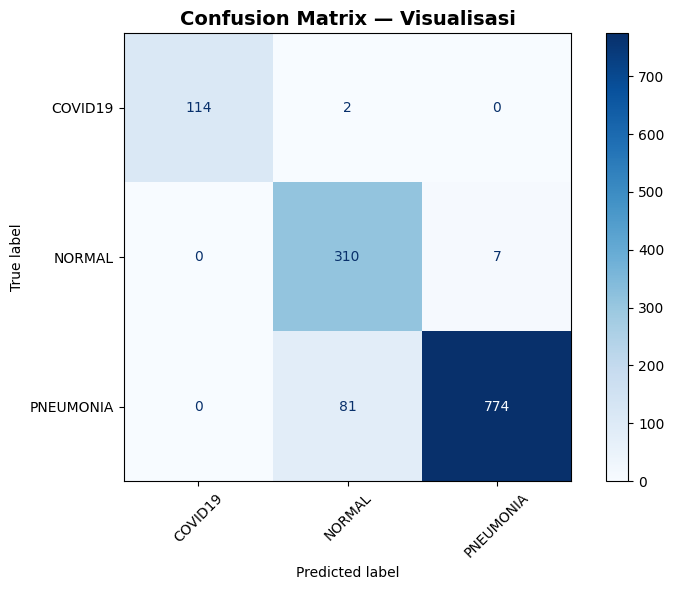

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

# Visualisasi confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=True)
ax.set_title("Confusion Matrix — Visualisasi", fontsize=14, fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

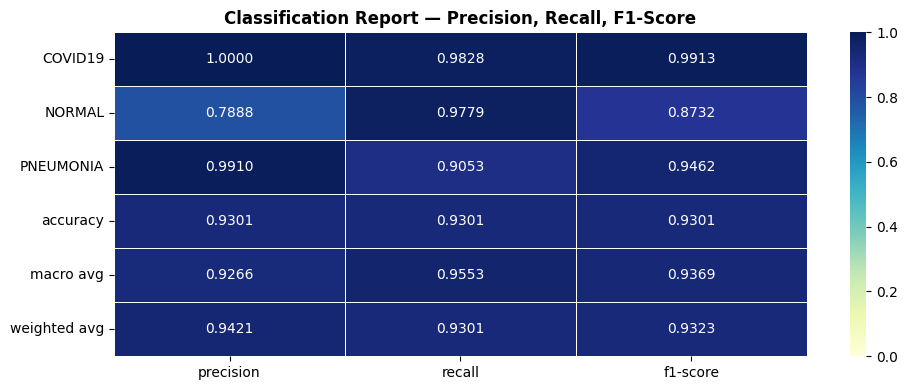

In [17]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()
df_report = df_report.loc[CLASS_NAMES + ["accuracy", "macro avg", "weighted avg"]]
df_report = df_report[["precision", "recall", "f1-score", "support"]].round(4)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    df_report.drop(columns="support").astype(float),
    annot=True, fmt=".4f", cmap="YlGnBu",
    linewidths=0.5, ax=ax,
    vmin=0, vmax=1
)
ax.set_title("Classification Report — Precision, Recall, F1-Score", 
             fontsize=12, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [2]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Model

base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x      = base_model.output
x      = Flatten()(x)
x      = Dense(4096, activation="relu")(x)
x      = Dropout(0.5)(x)
x      = Dense(4096, activation="relu")(x)
x      = Dropout(0.5)(x)
x      = BatchNormalization()(x)
output = Dense(3, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

# Langsung tampilkan summary tanpa training
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4096)           │        16,38

 Total params: 134,289,219 (512.27 MB)

 Trainable params: 119,566,339 (456.11 MB)

 Non-trainable params: 14,722,880 (56.16 MB)